CPI vs S&P 500 - Statistical Relationship Analysis

Goal: investigate whether Consumer Price Index (CPI) and Standard and Poor's 500 (S&P 500) performance are correlated.

Source of datasets: https://www.kaggle.com/datasets/rosicky1234/cpi-and-sp500$0

License - CC0: Public Domain

In [1]:
#import libraries
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#import S&P 500 raw data
cols = ['date', 'open', 'close', 'high', 'low']
df_sp500 = pd.read_csv('SP500.csv', names = cols)

In [3]:
#check the file was imported with the right columns by looking at the first five rows
df_sp500.head()

,date,open,close,high,low
0,Date,open,high,low,close
1,1/3/2000,1469.25,1478.00,1438.36,1455.22
2,1/4/2000,1455.22,1455.22,1397.43,1399.42
3,1/5/2000,1399.42,1413.27,1377.68,1402.11
4,1/6/2000,1402.11,1411.90,1392.10,1403.45


In [4]:
df_sp500.drop(0, inplace = True)
df_sp500.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5821 entries, 1 to 5821
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    5821 non-null   object
 1   open    5821 non-null   object
 2   close   5821 non-null   object
 3   high    5821 non-null   object
 4   low     5821 non-null   object
dtypes: object(5)
memory usage: 227.5+ KB


In [5]:
df_sp500.head()

,date,open,close,high,low
1,1/3/2000,1469.25,1478.00,1438.36,1455.22
2,1/4/2000,1455.22,1455.22,1397.43,1399.42
3,1/5/2000,1399.42,1413.27,1377.68,1402.11
4,1/6/2000,1402.11,1411.90,1392.10,1403.45
5,1/7/2000,1403.45,1441.47,1400.73,1441.47


In [6]:
#load the CPI dataset

df_cpi = pd.read_csv ('CPI.csv')

In [7]:
#check that the data loaded properly
df_cpi.head()

,Year,Month,Day,Actual,Predict,Previous,Diff_with_prev,Diff_with_predict
0,2012,5,15,0.023,0.023,0.027,0.004,0.000
1,2012,6,14,0.017,0.018,0.023,0.006,-0.001
2,2012,7,17,0.017,0.016,0.017,0.000,0.001
3,2012,8,15,0.014,0.016,0.017,0.003,-0.002
4,2012,9,14,0.017,0.017,0.014,-0.003,0.000


In [8]:
df_cpi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               130 non-null    int64  
 1   Month              130 non-null    int64  
 2   Day                130 non-null    int64  
 3   Actual             130 non-null    float64
 4   Predict            130 non-null    float64
 5   Previous           130 non-null    float64
 6   Diff_with_prev     130 non-null    float64
 7   Diff_with_predict  130 non-null    float64
dtypes: float64(5), int64(3)
memory usage: 8.3 KB


In [9]:
#The S&P dataset has the date formatted in month/day/year, meanwhile the CPI dataset has the date in separate 'Year', 'Month', 'Day' columns.
##Must make the formats the same to be able to combine the datasets for analysis

###convert current formats to datetime

from datetime import date


In [10]:
df_sp500["Date"] = pd.to_datetime(df_sp500['date'], format='mixed')
#used format = 'mixed' because upon checking the csv file, there were dates that used four digit years and some that used only two

In [11]:
df_sp500.head()

,date,open,close,high,low,Date
1,1/3/2000,1469.25,1478.00,1438.36,1455.22,2000-01-03
2,1/4/2000,1455.22,1455.22,1397.43,1399.42,2000-01-04
3,1/5/2000,1399.42,1413.27,1377.68,1402.11,2000-01-05
4,1/6/2000,1402.11,1411.90,1392.10,1403.45,2000-01-06
5,1/7/2000,1403.45,1441.47,1400.73,1441.47,2000-01-07


In [12]:
df_cpi["Date"] = pd.to_datetime (df_cpi[['Year', 'Month', 'Day']])

In [13]:
df_cpi.head()

,Year,Month,Day,Actual,Predict,Previous,Diff_with_prev,Diff_with_predict,Date
0,2012,5,15,0.023,0.023,0.027,0.004,0.000,2012-05-15
1,2012,6,14,0.017,0.018,0.023,0.006,-0.001,2012-06-14
2,2012,7,17,0.017,0.016,0.017,0.000,0.001,2012-07-17
3,2012,8,15,0.014,0.016,0.017,0.003,-0.002,2012-08-15
4,2012,9,14,0.017,0.017,0.014,-0.003,0.000,2012-09-14


In [14]:
# The next problem with the imported datasets are:
## 1) S&P 500 is daily data, whereas CPI is monthly, we need to resample S&P data to monthly
## 2) They don't have the same date range. CPI data starts in 2012.

In [15]:
df_sp500_monthly = df_sp500.set_index('Date').resample('ME').agg({
    'open': 'first',   # first open of the month
    'high': 'max',     # highest high of the month
    'low': 'min',      # lowest low of the month
    'close': 'last'    # last close of the month
}).reset_index()

In [16]:
df_sp500_monthly = df_sp500_monthly[df_sp500_monthly['Date'] >= '2012-01-01']

In [17]:
df_sp500_monthly.head()

,Date,open,high,low,close
144,2012-01-31,1258.86,1313.60,1277.06,1321.41
145,2012-02-29,1312.45,1365.97,1324.09,1378.04
146,2012-03-31,1365.90,1411.95,1343.36,1410.89
147,2012-04-30,1408.47,1404.62,1358.59,1403.26
148,2012-05-31,1397.86,1395.73,1295.22,1319.74


In [18]:
#the CPI dates are mid-month versus the sp500 dates which are at the end of the month, so these must align prior to merging
##normalize both to month-start

print(df_sp500_monthly.index)
print(df_sp500_monthly.columns)

df_sp500_monthly['Date'] = df_sp500_monthly['Date'].dt.to_period('M').dt.to_timestamp()
print(df_sp500_monthly['Date'].head())


Index([144, 145, 146, 147, 148, 149, 150, 151, 152, 153,
       ...
       268, 269, 270, 271, 272, 273, 274, 275, 276, 277],
      dtype='int64', length=134)
Index(['Date', 'open', 'high', 'low', 'close'], dtype='object')
144   2012-01-01
145   2012-02-01
146   2012-03-01
147   2012-04-01
148   2012-05-01
Name: Date, dtype: datetime64[ns]


In [19]:
print(df_cpi.columns)
print(df_cpi.index)

Index(['Year', 'Month', 'Day', 'Actual', 'Predict', 'Previous',
       'Diff_with_prev', 'Diff_with_predict', 'Date'],
      dtype='object')
RangeIndex(start=0, stop=130, step=1)


In [20]:
df_cpi = df_cpi.reset_index()
df_cpi['Date'] = df_cpi['Date'].dt.to_period('M').dt.to_timestamp()
df_sp500_monthly['Date'] = df_sp500_monthly['Date'].dt.to_period('M').dt.to_timestamp()


In [21]:
#check cpi and sp500 indexes

print(df_cpi.index)


RangeIndex(start=0, stop=130, step=1)


In [22]:
print(df_sp500_monthly.index)

Index([144, 145, 146, 147, 148, 149, 150, 151, 152, 153,
       ...
       268, 269, 270, 271, 272, 273, 274, 275, 276, 277],
      dtype='int64', length=134)


In [23]:
df_merged = pd.merge(df_sp500_monthly, df_cpi, on='Date', how='inner')
print(df_merged.shape)

(130, 14)


In [24]:
df_merged.head()

,Date,open,high,low,close,index,Year,Month,Day,Actual,Predict,Previous,Diff_with_prev,Diff_with_predict
0,2012-05-01,1397.86,1395.73,1295.22,1319.74,0,2012,5,15,0.023,0.023,0.027,0.004,0.000
1,2012-06-01,1309.87,1346.45,1278.04,1362.17,1,2012,6,14,0.017,0.018,0.023,0.006,-0.001
2,2012-07-01,1362.33,1381.37,1334.76,1387.16,2,2012,7,17,0.017,0.016,0.017,0.000,0.001
3,2012-08-01,1379.32,1414.67,1365.00,1413.09,3,2012,8,15,0.014,0.016,0.017,0.003,-0.002
4,2012-09-01,1406.54,1460.07,1403.44,1447.13,4,2012,9,14,0.017,0.017,0.014,-0.003,0.000


In [25]:
# I don't want all the columns from CPI in my merged dataset. I just want 'Actual'
df_merged = df_merged[['Date', 'open', 'high', 'low', 'close', 'Actual']]
print(df_merged.shape)
print(df_merged.head())

(130, 6)
        Date     open     high      low    close  Actual
0 2012-05-01  1397.86  1395.73  1295.22  1319.74   0.023
1 2012-06-01  1309.87  1346.45  1278.04  1362.17   0.017
2 2012-07-01  1362.33  1381.37  1334.76  1387.16   0.017
3 2012-08-01  1379.32  1414.67  1365.00  1413.09   0.014
4 2012-09-01  1406.54  1460.07  1403.44  1447.13   0.017


In [26]:
df_merged.rename (columns = {'Actual':'CPI'}, inplace = True)

In [27]:
df_merged.head()

,Date,open,high,low,close,CPI
0,2012-05-01,1397.86,1395.73,1295.22,1319.74,0.023
1,2012-06-01,1309.87,1346.45,1278.04,1362.17,0.017
2,2012-07-01,1362.33,1381.37,1334.76,1387.16,0.017
3,2012-08-01,1379.32,1414.67,1365.00,1413.09,0.014
4,2012-09-01,1406.54,1460.07,1403.44,1447.13,0.017


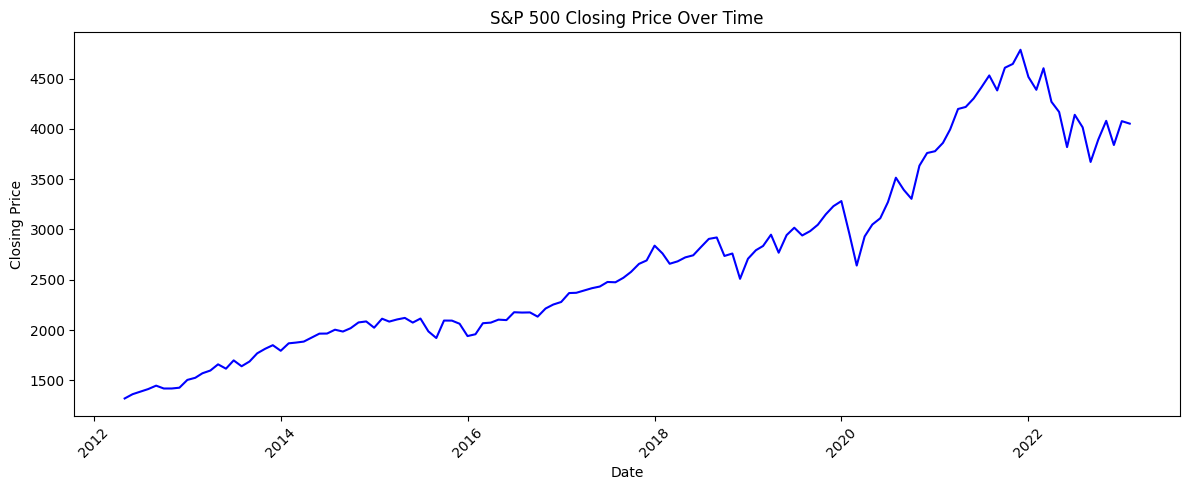

In [28]:
#Visualizations:
## S&P 500 closing price over time - line plot of close vs Date

#make sure values are numeric so they can be plotted
df_merged['close'] = pd.to_numeric(df_merged['close'])
df_merged['open'] = pd.to_numeric(df_merged['open'])
df_merged['high'] = pd.to_numeric(df_merged['high'])
df_merged['low'] = pd.to_numeric(df_merged['low'])

#sort by date to make sure the line plots correctly
df_merged = df_merged.sort_values('Date').reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.plot(df_merged['Date'], df_merged['close'], color='blue')
plt.title('S&P 500 Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
#checking on the data types to make sure they're correct
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    130 non-null    datetime64[ns]
 1   open    130 non-null    float64       
 2   high    130 non-null    float64       
 3   low     130 non-null    float64       
 4   close   130 non-null    float64       
 5   CPI     130 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 6.2 KB


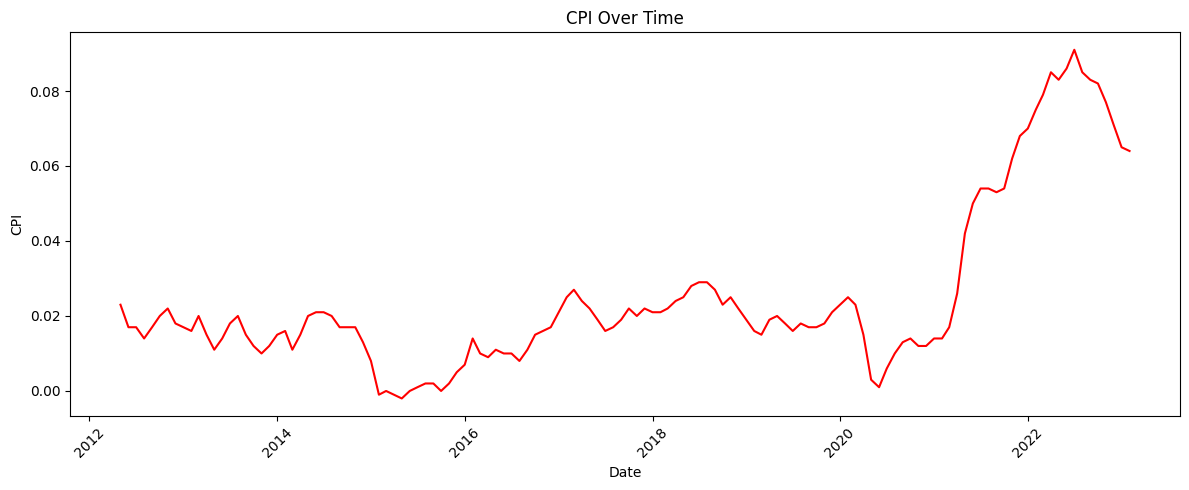

In [30]:
#Visualization: CPI over time

plt.figure(figsize=(12,5))
plt.plot (df_merged['Date'], df_merged['CPI'], color = 'red')
plt.title ('CPI Over Time')
plt.xlabel ('Date')
plt.ylabel ('CPI')
plt.xticks (rotation = 45)
plt.tight_layout()
plt.show()

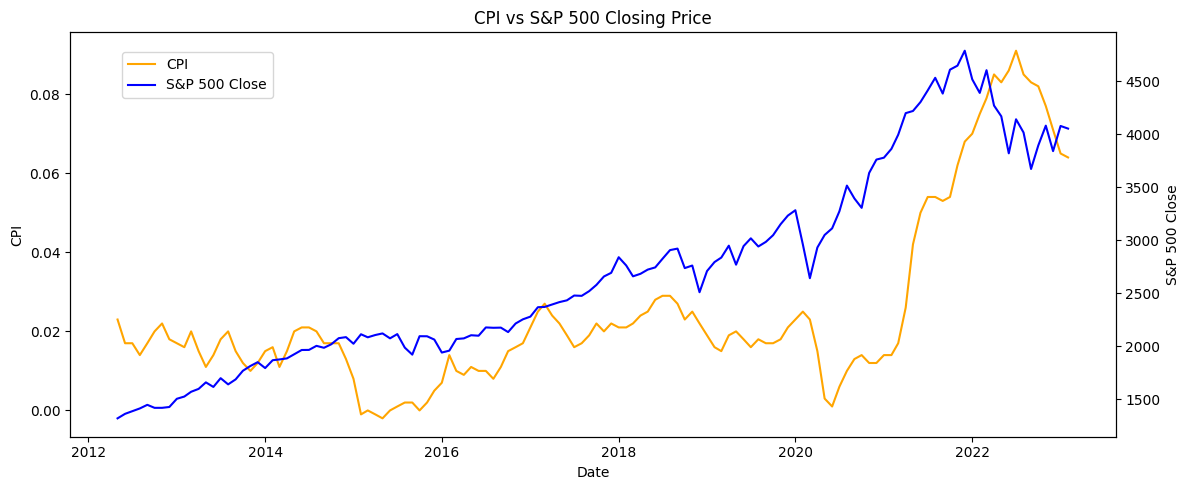

In [31]:
#overlap the visualizations to compare them

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(df_merged['Date'], df_merged['CPI'], label='CPI', color='orange')
ax1.set_xlabel('Date')
ax1.set_ylabel('CPI')

ax2 = ax1.twinx()
ax2.plot(df_merged['Date'], df_merged['close'], label='S&P 500 Close', color='blue')
ax2.set_ylabel('S&P 500 Close')

fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.title('CPI vs S&P 500 Closing Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

From the plot, it seems that these two time series data have a similar trend. However, this dual-axis chart can be misleading when I used twinx() to plot two series with completely different scales on the same chart, matplotlib independently scaled each y-axis to make each line fill the plot area nicely.

This means:

* The left axis stretches to fit CPI values (~0.01 to 0.08)
* The right axis stretches to fit S&P 500 values (~1,300 to 4,500)


The result is that both will look roughly similar in shape regardless of what the actual relationship is.
This is why I check for pearson r correlation next.

In [32]:
#Confirm there are no null values to deal with prior to further analysis

has_nan = df_merged.isnull().values.any()
print(f'DataFrame contains NaN values: {has_nan}')


DataFrame contains NaN values: False


In [33]:
#Check for correlation:
##pearson r

from scipy.stats import pearsonr

correlation, pvalue = pearsonr(df_merged['CPI'], df_merged['close'])
print(f'Pearson correlation coefficient: {correlation:.4f}')
print(f'P-value: {pvalue:.4f}')
print(f'Statistically significant: {pvalue < 0.05}')

Pearson correlation coefficient: 0.7151
P-value: 0.0000
Statistically significant: True


A strong positive correlation was found (r = 0.7151, p < 0.0001), statistically significant at the 0.05 level.

In [34]:
'''Granger Causality Test to check whether CPI can predict S&P 500 or vice versa.
Check for stationarity first
Why? the Granger Causality Test assumes both time series are stationary - meaning their
mean and variance don't change over time.
If the data is non-stationary, the test results can be spurious, meaning it might show a relationship
between the two variables even when there isn't one. This is a common issue with financial and economic time series like
S&P 500 and CPI, which tend to trend upward over time.
The Augmented Dickey-Fuller (ADF) test can be used to check for stationarity.
'''

from statsmodels.tsa.stattools import adfuller

def adf_test(series):
  res = adfuller (series, autolag = 'AIC')
  if res [1] < 0.05:
    print ('Stationary')
  else:
    print ('Non-stationary')

In [35]:
adf_test (df_merged['close'])
adf_test (df_merged ['CPI'])


Non-stationary
Non-stationary


In [36]:
'''The p-values for both datasets is above 0.05 indicating they're non-stationary
A possible fix is to difference the data (subtract each value from the previous one), which removes the trend:
'''

df_merged['close_diff'] = df_merged['close'].diff()
df_merged['CPI_diff'] = df_merged['CPI'].diff()



In [37]:
#Complete an adf test on the new values
##drop na had to be used because the first row has no previous value to subtract from, so it becomes NaN which the ADF test can't handle

adf_test (df_merged['close_diff'].dropna())
adf_test (df_merged['CPI_diff'].dropna())

Stationary
Non-stationary


In [38]:
'''Since the CPI data remains non-stationary after the first differencing, the options
are to either try differencing a second time or use a log transformation prior to differencing

I'll try a second order differencing first
'''

df_merged['CPI_diff2'] = df_merged['CPI_diff'].diff()

In [39]:
adf_test (df_merged['CPI_diff2'].dropna())

Stationary


The inflation rate required second-order differencing to become stationary, which means I'm now working with the acceleration of price changes and not inflation itself. And SP_diff lost one row due to first-order differentiation while CPI_diff2 lost 2 rows due to second-order differentiation. The dropna() on concat dealt with it, but I ended up with less rows for comparison as seen in the check below (cell 45)

In [40]:
#rename the datasets to make it easier to refer to them in the test

SP_diff = df_merged['close_diff'].dropna()
CPI_diff2 = df_merged['CPI_diff2'].dropna()


In [41]:
SP_diff.head()

,close_diff
1,42.43
2,24.99
3,25.93
4,34.04
5,-28.37


In [42]:
CPI_diff2.head()

,CPI_diff2
2,6.000000e-03
3,-3.000000e-03
4,6.000000e-03
5,-1.734723e-18
6,-1.000000e-03


Now that both are stationary, it's time to complete the Granger Causality test

In [43]:
from statsmodels.tsa.stattools import grangercausalitytests

In [44]:
max_lag = 4
data = pd.concat ([SP_diff, CPI_diff2], axis = 1).dropna()

In [45]:
print(f'SP_diff length: {len(SP_diff)}')
print(f'CPI_diff2 length: {len(CPI_diff2)}')
print(f'Data used in Granger test: {len(data)} rows')

SP_diff length: 129
CPI_diff2 length: 128
Data used in Granger test: 128 rows


Granger Causality Test 1: Does CPI Granger-cause S&P 500?

In [46]:
results = grangercausalitytests(data[['close_diff', 'CPI_diff2']], max_lag)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=3.8475  , p=0.0521  , df_denom=124, df_num=1
ssr based chi2 test:   chi2=3.9405  , p=0.0471  , df=1
likelihood ratio test: chi2=3.8806  , p=0.0488  , df=1
parameter F test:         F=3.8475  , p=0.0521  , df_denom=124, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.9349  , p=0.0569  , df_denom=121, df_num=2
ssr based chi2 test:   chi2=6.1124  , p=0.0471  , df=2
likelihood ratio test: chi2=5.9687  , p=0.0506  , df=2
parameter F test:         F=2.9349  , p=0.0569  , df_denom=121, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2.2334  , p=0.0879  , df_denom=118, df_num=3
ssr based chi2 test:   chi2=7.0977  , p=0.0688  , df=3
likelihood ratio test: chi2=6.9035  , p=0.0750  , df=3
parameter F test:         F=2.2334  , p=0.0879  , df_denom=118, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=2.2399  , p=0.0690  

Results:


*   Lag 1: range of p = 0.0488 to 0.0521, with an average of 0.0500
*   Lag 2: range of p = 0.0471 to 0.0569, with an average of 0.0529
*   Lag 3: range of p = 0.0688 to 0.0879
*   Lag 4: range of p = 0.0465 to 0.0690, with an average of 0.0596

Conclusion: The p-values at lags 1,2, and 4 are all hovering right at the 0.05 boundary. Therefore, CPI does not strongly Granger-cause S&P 500--there's a weak suggestive signal but not statistically significant at the 0.05 level.





Granger Causality Test 2: Does S&P 500 Granger-cause CPI?

In [47]:
#reverse the order
results2 = grangercausalitytests(data[['CPI_diff2', 'close_diff']], max_lag)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.8915  , p=0.3469  , df_denom=124, df_num=1
ssr based chi2 test:   chi2=0.9131  , p=0.3393  , df=1
likelihood ratio test: chi2=0.9098  , p=0.3402  , df=1
parameter F test:         F=0.8915  , p=0.3469  , df_denom=124, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=4.0021  , p=0.0207  , df_denom=121, df_num=2
ssr based chi2 test:   chi2=8.3348  , p=0.0155  , df=2
likelihood ratio test: chi2=8.0708  , p=0.0177  , df=2
parameter F test:         F=4.0021  , p=0.0207  , df_denom=121, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=3.8874  , p=0.0109  , df_denom=118, df_num=3
ssr based chi2 test:   chi2=12.3539 , p=0.0063  , df=3
likelihood ratio test: chi2=11.7809 , p=0.0082  , df=3
parameter F test:         F=3.8874  , p=0.0109  , df_denom=118, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=3.1765  , p=0.0162  

Results:


*   Lag 1: range of p = 0.3393 to 0.3469, which is way above 0.05
*   Lag 2: range of p = 0.0155 to 0.0207, with an average of p = 0.0187
*   Lag 3: range of p = 0.0063 to 0.0109, with an average of p = 0.0091
*   Lag 4: range of p = 0.0083 to 0.0162, with an average of p = 0.0130

Conclusion: S&P 500 does Granger-cause CPI -- past stock mark movements have statistically predictive power over future CPI changes, with a lag of 2-4 months.




# **Overall Takeaways:**

The analysis reveals a positive correlation between the S&P 500 and CPI. Furthermore, the Granger causality test suggests this relationship is one-directional — past stock market movements appear to predict future changes in inflation, but not vice versa.

Notes:

* Granger causality does not imply true economic causality — it only indicates predictive power within this statistical framework.
* And S&P 500 past values help predict CPI better than CPI's own past values alone, but Granger causality is not true causality.

# **Limitations:**
* Despite the S&P 500 dataset spanning over two decades, the analysis was constrained by the CPI dataset, which only begins in 2012. This left just 130 data points for comparison, which limits the robustness of the findings.
* A CPI dataset with a longer historical range would allow for a more comprehensive and reliable analysis.
* Pearson correlation assumes a linear relationship — the CPI vs S&P 500 relationship may not be linear
* The inner join silently drops months where one dataset had no data
* External confounders (interest rates, GDP, global events) not accounted for